In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
df=pd.read_csv("indian_ecommerce.csv")
df

,order_id,order_date,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,units_sold,revenue,sales_event,competition_intensity,inventory_pressure
0,ORD0000001,2023-01-31,West Bengal,East,Fashion,Mass,Male,28,1810.89,65.00,633.81,29,18380.49,Normal,Medium,High
1,ORD0000002,2023-01-31,Gujarat,West,Sports & Fitness,Mass,Male,19,5678.15,50.83,2791.95,67,187060.65,Normal,Medium,High
2,ORD0000003,2023-01-31,Delhi NCR,North,Grocery Essentials,Mass,Male,25,169.98,35.26,110.05,57,6272.85,Normal,Medium,Low
3,ORD0000004,2023-01-31,Madhya Pradesh,Central,Footwear,Mass,Female,30,3244.91,61.94,1235.01,55,67925.55,Normal,High,High
4,ORD0000005,2023-01-31,Haryana,North,Fashion,Premium,Female,33,697.44,48.27,360.79,29,10462.91,Festival,Medium,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30595,ORD0030596,2025-12-31,Uttar Pradesh,North,Premium Lifestyle,Mass,Male,54,12463.98,38.99,7604.27,11,83646.97,Normal,Medium,Low
30596,ORD0030597,2025-12-31,Haryana,North,Footwear,Premium,Male,18,3974.58,39.35,2410.58,20,48211.60,Festival,Low,Low
30597,ORD0030598,2025-12-31,Odisha,East,Footwear,Mass,Female,58,3020.42,65.00,1057.15,59,62371.85,Festival,High,Low
30598,ORD0030599,2025-12-31,West Bengal,East,Sports & Fitness,Mass,Female,23,1212.05,12.35,1062.36,8,8498.88,Normal,Medium,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30600 non-null  object 
 1   order_date             30600 non-null  object 
 2   state                  30600 non-null  object 
 3   zone                   30600 non-null  object 
 4   category               30600 non-null  object 
 5   brand_type             30600 non-null  object 
 6   customer_gender        30600 non-null  object 
 7   customer_age           30600 non-null  int64  
 8   base_price             30600 non-null  float64
 9   discount_percent       30600 non-null  float64
 10  final_price            30600 non-null  float64
 11  units_sold             30600 non-null  int64  
 12  revenue                30600 non-null  float64
 13  sales_event            30600 non-null  object 
 14  competition_intensity  30600 non-null  object 
 15  in

In [5]:
df.isna().sum()

order_id                 0
order_date               0
state                    0
zone                     0
category                 0
brand_type               0
customer_gender          0
customer_age             0
base_price               0
discount_percent         0
final_price              0
units_sold               0
revenue                  0
sales_event              0
competition_intensity    0
inventory_pressure       0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df['order_date']=pd.to_datetime(df['order_date'])

In [8]:
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year

In [9]:
df.groupby('category')['revenue'].sum().sort_values(ascending=False)

category
Premium Lifestyle         6.480969e+08
Electronics               5.205175e+08
Sports & Fitness          2.833666e+08
Home & Living             2.366783e+08
Footwear                  1.957683e+08
Fashion                   1.578753e+08
Beauty & Personal Care    1.016232e+08
Grocery Essentials        3.058428e+07
Name: revenue, dtype: float64

In [10]:
df.groupby('state')['revenue'].sum().sort_values(ascending=False)

state
Delhi NCR         1.956911e+08
Maharashtra       1.894436e+08
Karnataka         1.887672e+08
Kerala            1.683534e+08
Gujarat           1.682156e+08
Telangana         1.669118e+08
Tamil Nadu        1.654015e+08
Punjab            1.586658e+08
Haryana           1.572334e+08
Madhya Pradesh    1.312256e+08
Uttar Pradesh     1.249221e+08
West Bengal       1.224628e+08
Odisha            1.218676e+08
Chhattisgarh      1.153489e+08
Name: revenue, dtype: float64

In [11]:
df.groupby('zone')['revenue'].sum().sort_values(ascending=False)

zone
South      6.894339e+08
North      6.365123e+08
West       3.576592e+08
Central    2.465746e+08
East       2.443304e+08
Name: revenue, dtype: float64

In [12]:
df.groupby('brand_type')['revenue'].sum()

brand_type
Mass       1.604407e+09
Premium    5.701032e+08
Name: revenue, dtype: float64

In [13]:
df.groupby('discount_percent')['units_sold'].mean()

discount_percent
0.01      9.00000
0.02      5.00000
0.10     16.00000
0.14     13.00000
0.16      8.00000
           ...   
64.96    77.00000
64.97    42.00000
64.98    72.00000
64.99    46.75000
65.00    49.91289
Name: units_sold, Length: 5976, dtype: float64

In [14]:
df.groupby('sales_event')['revenue'].sum().sort_values(ascending=False)

sales_event
Normal      1.413821e+09
Festival    7.606892e+08
Name: revenue, dtype: float64

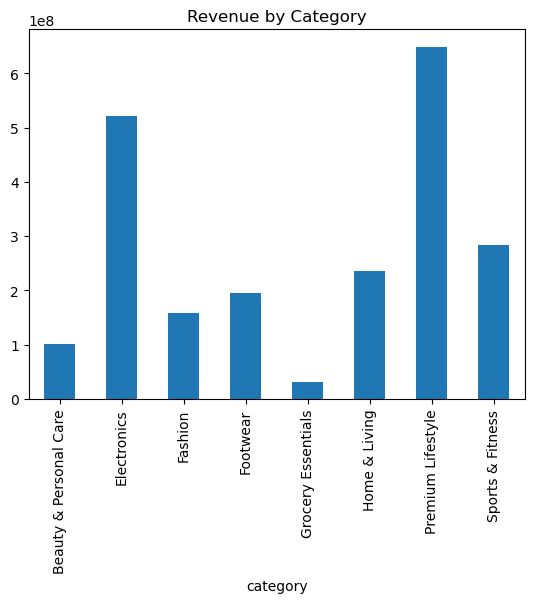

In [15]:
df.groupby('category')['revenue'].sum().plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

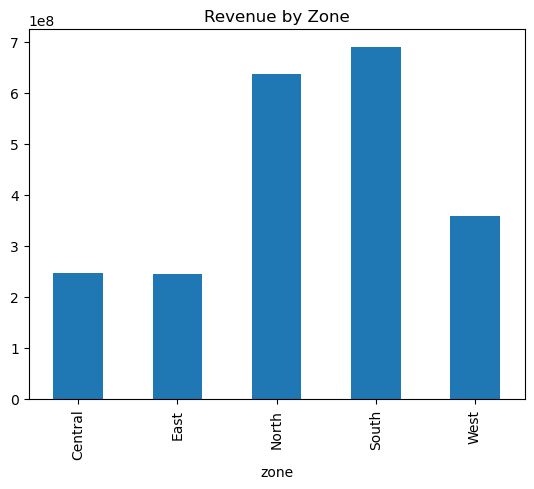

In [16]:
df.groupby('zone')['revenue'].sum().plot(kind='bar')
plt.title("Revenue by Zone")
plt.show()

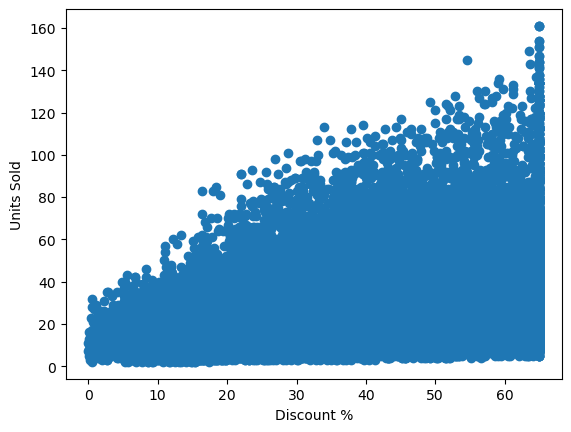

In [17]:
plt.scatter(df['discount_percent'], df['units_sold'])
plt.xlabel("Discount %")
plt.ylabel("Units Sold")
plt.show()

In [18]:
df.to_csv("ecommerce_clean.csv", index=False)